# Image Compression Using Singular Value Decomposition
---
Singular value decomposition (SVD) is an algorithm used to approximate and compress data in large matrices. While it can be used to condense large data sets, its most applicable use is for image compression.

Full SVD:  $ A = U \Sigma V^T $ </br>
Condensed SVD: $ A = \hat{U} \hat{\Sigma} \hat{V^T}$

#### Step 1: Displaying the Image

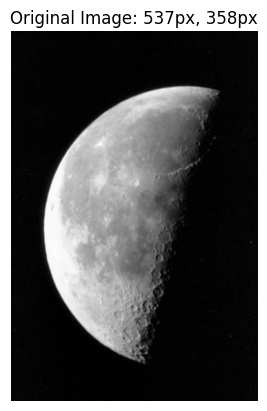

In [52]:
%matplotlib inline
import cv2 # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # pyright: ignore[reportMissingImports]


# define the images that will be used later
img_moon = 'moon.tif'
img_saturn = 'saturn.png'

img_data = cv2.imread(img_moon) # basic image read
img_rgb = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB) # color image read
img_gs = cv2.imread(img_moon, cv2.IMREAD_GRAYSCALE) # grayscale image read

# return the current image
def show_image(image, title:str):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

res = img_data.shape # resolution
show_image(img_data, f"Original Image: {res[0]}px, {res[1]}px") # display the image

#### Step 2: Image Datatypes
While I am using Python and not MATLAB I only have one option for datatypes. OpenCV stores images as an NumPy array that is composed of `uint8` values that represent each pixel. This is true for both color and grayscale images, execpt the color image has three layers: red, green, and blue. You can see in the code snippet below that I am returning the data type of the image after it has been read by openCV's built in feature `cv2.imread` and `cv2.cvtColor`. In my case, this data is currently stored in the variable `img_data` and `img_rgb`. I am also returning the size of the matrix that is created to show the three color layers that are present in the color image.

In [42]:
print(f"Image datatype in color: {img_data.dtype}")
print(f"Size of the color image matrix: {img_rgb.shape}")
print(f"Image datatype in grayscale: {img_gs.dtype}")
print(f"Size of the grayscale image matrix: {img_gs.shape}")

Image datatype in color: uint8
Size of the color image matrix: (537, 358, 3)
Image datatype in grayscale: uint8
Size of the grayscale image matrix: (537, 358)


##### Steps 3 + 4: Computing SVD

I can perform SVD using the NumPy's built in `np.linalg.svd()` function which takes in a matrix like the one previously stored in the variable `img_gs` and outputs the matrices U and V. For S, only the diagonal values or the singular values are returned. The input argument `full_matrices` determines if the complete SVD is being calulated or if a reduced version should be calculated. For this example, I have set `full_matrices` to true. Looking at the code snippet below, you can see Ive stored these values in matrices U, S, and V.

In [ ]:
U, S, Vt = np.linalg.svd(img_gs, full_matrices=True) # full_matrices=True means that the full SVD is being calculated, setting it to false returns a reduced SVD

num_of_values = len(S)
print(f"dimensions of U:{U.shape}")
print(f"number of singular values in S: {num_of_values}") # S is a 1D array instead of a matrix/2D array because S contains only the diagonal values. (also equals the number of columns in S)
print(f"dimensions of Vt:{Vt.shape}")

dimensions of U:(537, 537)
number of singular values in S: 358
dimensions of Vt:(358, 358)


##### Step 5: Low Rank Approximation
Written below is the equation for low rank approximation:
$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

- $A_k$ is the reduced approximated matrix
- $k$ represents the number of singular values to keep or are used
- $\sigma_i$ are the singular values
- $u_i$ and $v_i^T$ are the right and left singular vectors

##### Step 6: 
I decided to compress moon.tif to equally spaced singular values so that I could easily adjust them using a for loop in order to make my code reusable. I was able to tell what the image was around n=6, however that could definintely be dependent on the content of the image, for instance, I could not tell what the image was until n=15 for one of the trial runs I did with an jpeg image of flowers. I have displayed the results along with the code below.

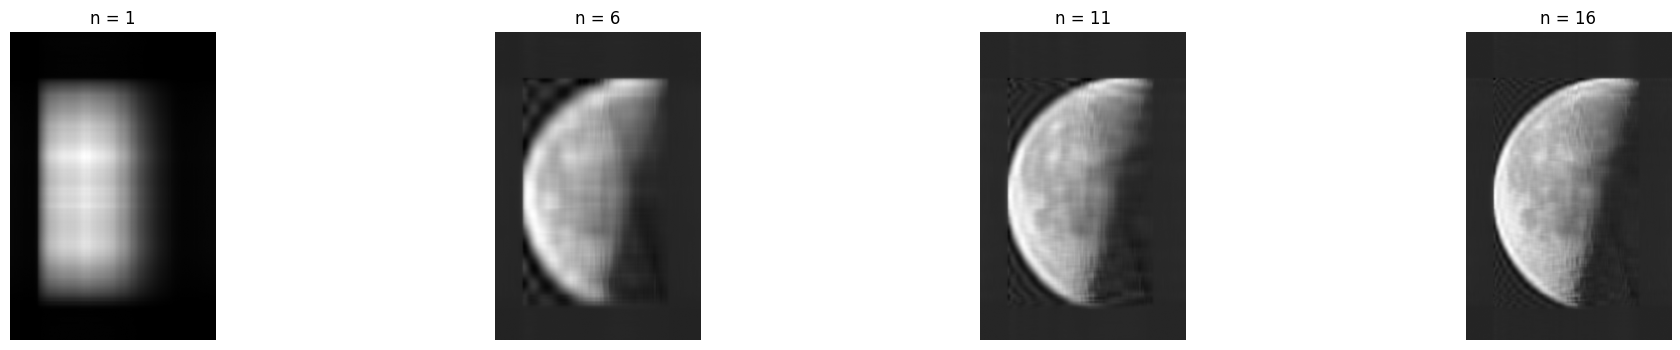

In [47]:
# for grayscale images / output
def svd_gs(image, sv):
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    gs_img = np.matrix(U[:,:sv]) * np.diag(S[:sv]) * np.matrix(Vt[:sv,:])
    return gs_img

# showing the effect after adding 5 more singular values each frame
plt.figure(figsize=(24,4))
start, end, step = 1, 20, 5

for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    img_gs = svd_gs(img_moon, i) # does the svd compression
    plt.imshow(img_gs, cmap='grey')
    plt.title('n = %s' % i)
    plt.axis('off')

plt.show()

#### Step 7: RMSE and PSNR
The quality of each rank-k approximation can be quantified using the Peak Signal-
to-Noise Ratio (PSNR), which uses the Root Mean Square Error (RMSE):

$$\text{PSNR}_k = 10 \log_{10} \left(\frac{(\text{max range})^2}{\text{RMSE}}\right)$$

$$\text{RMSE}_k = \sqrt{\frac{\sum_{i=1}^{m} \sum_{j=1}^{n} (A_{ij} - A_{k,ij})^2}{mn}}$$

Below the code snippet, you can see the output table that associates each rank with a calculated PSNR value.

In [ ]:
def calculate_psnr(original, compressed, max_range=255): # calculating psnr
    mse = np.mean((original - compressed) ** 2)
    rmse = np.sqrt(mse)  # calc RMSE
    if mse == 0:
        return float('inf')  # 100% reconstruction
    psnr = 20 * np.log10((max_range**2) / rmse) # psnr calculation
    return psnr

original_img = cv2.imread(img_moon, cv2.IMREAD_GRAYSCALE).astype(np.float64)

# use the same ranks as step 6
ranks = [1, 6, 11, 16]
psnr_values = []

for k in ranks: # for loop for efficiency
    compressed_img = svd_gs(img_moon, k)
    compressed_img = np.array(compressed_img).astype(np.float64)
    
    # calc psnr for each rank
    psnr = calculate_psnr(original_img, compressed_img)
    psnr_values.append(psnr)


results_df = pd.DataFrame({ # make table
    'Rank (k)': ranks,
    'PSNR (dB)': [f"{psnr:.2f}" for psnr in psnr_values]
})

print("\nPSNR Results Table:")
print(results_df.to_string(index=False))



PSNR Results Table:
 Rank (k) PSNR (dB)
        1     63.65
        6     72.51
       11     75.68
       16     77.88



#### Step 8: Explained Variance

$$v(k) = \frac{||A_k||_F}{||A||_F}$$
where $F$ denotes the Frobenius norm.

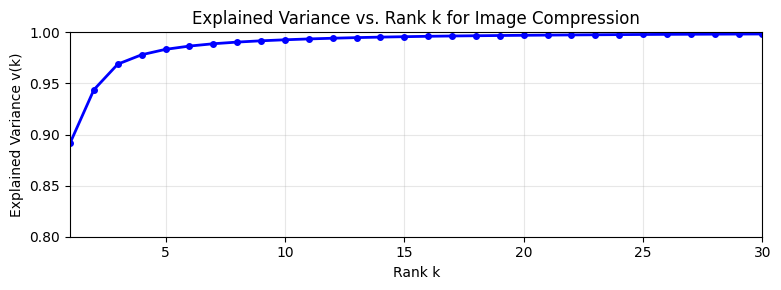

k = 2 needed to explain 90% of variance
k = 3 needed to explain 95% of variance
k = 8 needed to explain 99% of variance


In [ ]:
def calculate_explained_variance(image_path, max_k=50):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float64) # svd on image
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    
    f_norm_A = np.linalg.norm(img, 'fro') # f norm of A
    
    k_values = range(1, min(max_k + 1, len(S) + 1))
    exp_variance = []
    
    for k in k_values:
        A_k = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :])) # making Ak with the first k singular values
        
        f_norm_Ak = np.linalg.norm(A_k, 'fro') # f norm of Ak
        
        # calc explained variance v(k)
        v_k = f_norm_Ak / f_norm_A
        exp_variance.append(v_k)
    
    return k_values, exp_variance

k_values, variance_explained = calculate_explained_variance(img_moon, max_k=50)

# using matplotlib to show the graph
plt.figure(figsize=(8, 3))
plt.plot(k_values, variance_explained, 'b-o', markersize=4, linewidth=2)
plt.xlabel('Rank k')
plt.ylabel('Explained Variance v(k)')
plt.title('Explained Variance vs. Rank k for Image Compression')
plt.grid(True, alpha=0.3)
plt.xlim(1, 30)  
plt.ylim(0.8, 1.0) 
plt.tight_layout()
plt.show()

# thresholds/variance benchmarks
for threshold in [0.9, 0.95, 0.99]:
    k_needed = next((k for k, v in zip(k_values, variance_explained) if v >= threshold), None)
    if k_needed:
        print(f"k = {k_needed} needed to explain {threshold*100:.0f}% of variance")


#### Step 9: Image Color Channels + Full Color Image Compression

In order to compress a color image, I first read the image data using `cv2.imread` and then passed that data to `cv2.split` which splits the image into the three color channels as shown in the first code + output block. After that, I compressed each channel using `np.linalg.svd`, and made a comporessed image for each channel by multiplying them back together only using a specified rank. In order to maintain as much image data as possible, I used a rank of 15 as that should retain about 99% of the image quality as demonstrated in the previous step. To make the final image, which is the full color image but compressed, I utilized OpenCV's merge function which is used for merging color channels back together to make one image. 

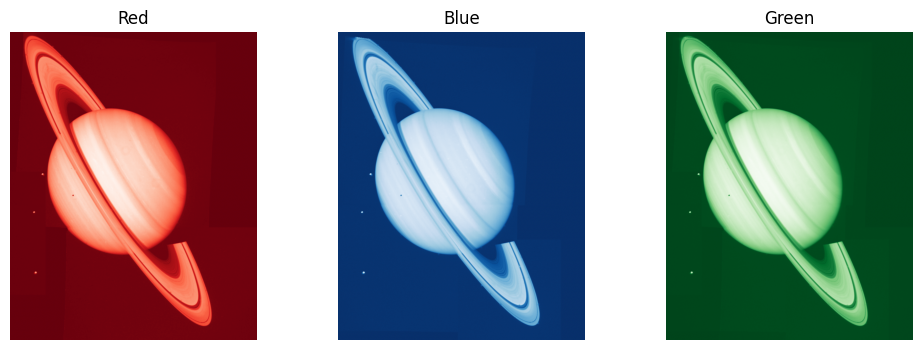

In [75]:
saturn_img_data = cv2.imread(img_saturn)
B, G, R = cv2.split(saturn_img_data) # splitting color channels using OpenCV

colors = ['Red', 'Blue', 'Green']
matrices = [R, B, G]

plt.figure(figsize=(12, 4))
for i in range(len((colors))):
    plt.subplot(1, 3, i+1)
    plt.title(colors[i])
    plt.imshow(matrices[i],cmap=f'{colors[i]}s_r')
    plt.axis('off')
plt.show()

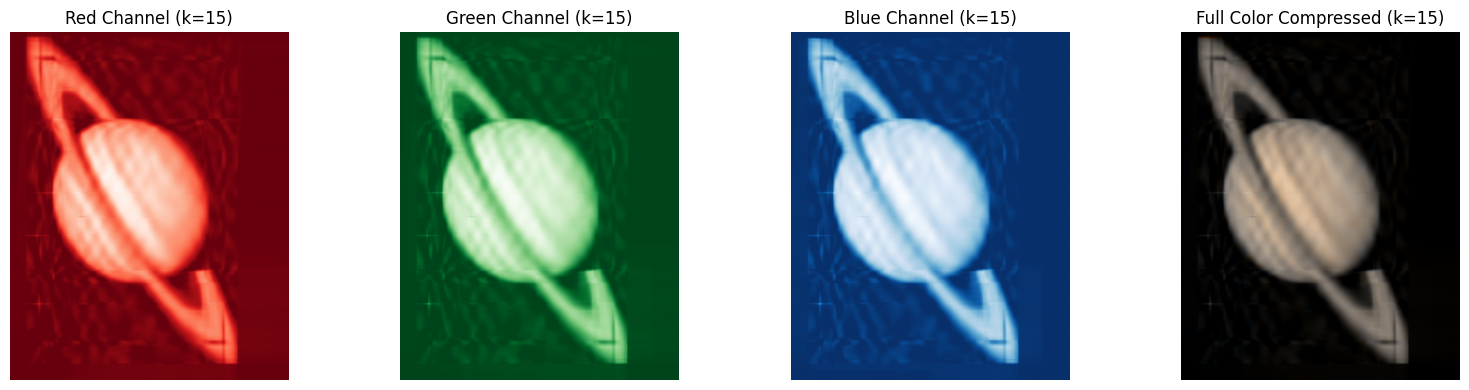

Framework 16: AMD Ryzen 7 7480HS
CPU times: user 17.2 s, sys: 141 ms, total: 17.3 s
Wall time: 1.64 s


In [82]:
%%time
def svd_color(image, sv):
    B, G, R = cv2.split(image)

    U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)
    U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
    U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)

    R_comp = np.matrix(U_r[:, :sv]) * np.diag(S_r[:sv]) * np.matrix(Vt_r[:sv, :])
    G_comp = np.matrix(U_g[:, :sv]) * np.diag(S_g[:sv]) * np.matrix(Vt_g[:sv, :])
    B_comp = np.matrix(U_b[:, :sv]) * np.diag(S_b[:sv]) * np.matrix(Vt_b[:sv, :])

    comp_full = cv2.merge([np.clip(R_comp, 1, 255), np.clip(G_comp, 1, 255), np.clip(B_comp, 1, 255)])
    comp_full = comp_full.astype(np.uint8)

    colors = ['Red', 'Blue', 'Green', 'Full Color']
    matrices = [R_comp, B_comp, G_comp, comp_full]


    R_comp = np.clip(R_comp, 0, 255)
    G_comp = np.clip(G_comp, 0, 255)
    B_comp = np.clip(B_comp, 0, 255)

    # full color color compressed image
    comp_full = cv2.merge([B_comp, G_comp, R_comp])  # OpenCV uses BGR order
    comp_full = comp_full.astype(np.uint8)

    # show compressed channels + final image
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.title(f'Red Channel (k={sv})')
    plt.imshow(R_comp, cmap='Reds_r')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title(f'Green Channel (k={sv})')
    plt.imshow(G_comp, cmap='Greens_r')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title(f'Blue Channel (k={sv})')
    plt.imshow(B_comp, cmap='Blues_r')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title(f'Full Color Compressed (k={sv})')
    plt.imshow(cv2.cvtColor(comp_full, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return comp_full

compressed_saturn = svd_color(saturn_img_data, 15)
print('Framework 16: AMD Ryzen 7 7480HS')

In [64]:
# Getting the singular values of the matrix S

sing_val_ex = cv2.imread(img_moon, cv2.IMREAD_GRAYSCALE)
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

np.set_printoptions(precision=1)  # 3 decimal places
print("Values of S:")
print(S)

Values of S:
[3.7e+04 1.3e+04 9.0e+03 5.5e+03 4.2e+03 3.3e+03 2.8e+03 2.3e+03 2.1e+03
 1.8e+03 1.7e+03 1.5e+03 1.4e+03 1.3e+03 1.2e+03 1.1e+03 1.0e+03 9.1e+02
 8.9e+02 8.4e+02 8.1e+02 7.6e+02 7.2e+02 7.1e+02 6.6e+02 6.3e+02 6.1e+02
 5.8e+02 5.6e+02 5.3e+02 5.3e+02 5.1e+02 4.8e+02 4.8e+02 4.6e+02 4.4e+02
 4.3e+02 4.2e+02 4.1e+02 3.9e+02 3.8e+02 3.8e+02 3.6e+02 3.5e+02 3.4e+02
 3.2e+02 3.2e+02 3.0e+02 3.0e+02 2.9e+02 2.9e+02 2.8e+02 2.8e+02 2.6e+02
 2.6e+02 2.5e+02 2.5e+02 2.4e+02 2.4e+02 2.4e+02 2.3e+02 2.3e+02 2.2e+02
 2.1e+02 2.1e+02 2.1e+02 2.0e+02 2.0e+02 2.0e+02 2.0e+02 1.9e+02 1.9e+02
 1.8e+02 1.8e+02 1.7e+02 1.7e+02 1.7e+02 1.6e+02 1.6e+02 1.6e+02 1.5e+02
 1.5e+02 1.5e+02 1.4e+02 1.4e+02 1.4e+02 1.3e+02 1.3e+02 1.3e+02 1.3e+02
 1.3e+02 1.3e+02 1.2e+02 1.2e+02 1.2e+02 1.2e+02 1.1e+02 1.1e+02 1.1e+02
 1.1e+02 1.1e+02 1.1e+02 1.0e+02 1.0e+02 1.0e+02 1.0e+02 9.9e+01 9.8e+01
 9.6e+01 9.4e+01 9.3e+01 9.1e+01 8.9e+01 8.9e+01 8.8e+01 8.7e+01 8.6e+01
 8.4e+01 8.3e+01 8.2e+01 8.2e+01 8.1e+

In [39]:
%%time
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=True)

CPU times: user 1.02 s, sys: 881 μs, total: 1.02 s
Wall time: 71.7 ms


In [38]:
%%time
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

CPU times: user 537 ms, sys: 0 ns, total: 537 ms
Wall time: 39.6 ms


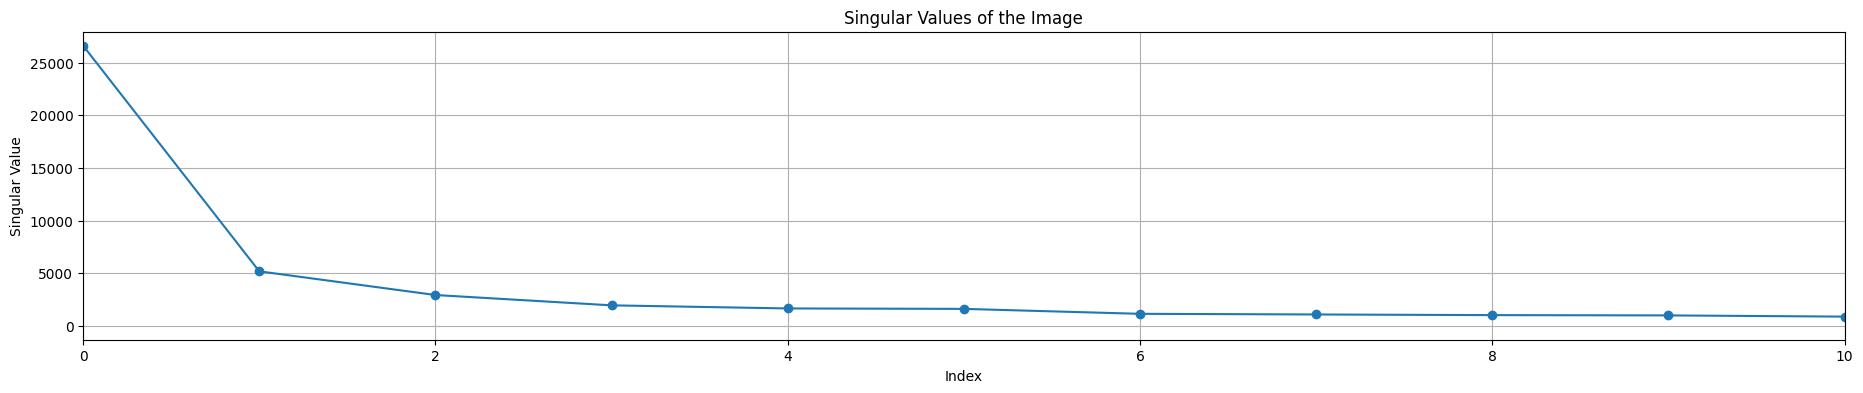

In [31]:
plt.figure(figsize=(50,4))
plt.subplot(1, 2, 1)
plt.plot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.xlim(0, 10) 
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()